In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

In [9]:
translate_maps = {
    "HIGH_LOAD": "HL"
}

In [10]:
instance_progression = {
    "50": {},
    "150": {},
    "650": {},
    "1000": {}
}
csv_files = glob.glob('simulated/*.csv')
for instance_file in csv_files:
    instance = pd.read_csv(instance_file)
    instance_info = instance_file.split(".")[0].split("-")
    instance_alg = instance_info[4]
    if instance_alg == "A":
        instance_capacity = instance_info[5]
        vams = instance_info[7]
        instance_name = f"Algorithm A (VAms={translate_maps[vams]})"
    elif instance_alg == "B":
        instance_capacity = instance_info[5]
        cr = instance_info[6]
        omsms = instance_info[7]
        omsdtp = instance_info[8]
        vams = instance_info[10]
        vadtp = instance_info[11]
        instance_name = f"Algorithm B (config 6)"
    else:
        emsms = instance_info[5]
        emsdtp = instance_info[6]
        instance_capacity = instance_info[7]
        omsms = instance_info[8]
        omsdtp = instance_info[9]
        cr = instance_info[10]
        pams = instance_info[11]
        ocr = instance_info[12]
        dmsms = instance_info[14]
        if pams == "ROUND_ROBIN":
            instance_name = f"Algorithm C (config 6)"
        else:
            continue
    instance_progression[instance_capacity][instance_name] = {
        "viewer_count_array": [],
        "viewer_count": 0,
        "viewer_count_session": {},
        "sessions": []
    }
    viewer_count = 0
    viewer_count_array = instance_progression[instance_capacity][instance_name]["viewer_count_array"]
    sessions = instance_progression[instance_capacity][instance_name]["sessions"]
    viewer_count_session = instance_progression[instance_capacity][instance_name]["viewer_count_session"]
    for _, row in instance.iterrows():
        if row["instance_event"] == 0:
            session = row["id"]
            viewer_count_session[session] = {
                "viewer_count": 0,
                "viewer_count_array": [0],
            }
            if len(sessions) == 0:
                sessions.append(1)
            else:
                sessions.append(sessions[-1] + 1)
        elif row["instance_event"] == 2:
            session = row["id"]
            viewer_count -= viewer_count_session[session]["viewer_count"]
            sessions.append(sessions[-1] - 1)
        elif row["instance_event"] == 1:
            session = '-'.join(row["id"].split("-")[:-1])
            viewer_count_session[session]["viewer_count"] += 1
            viewer_count_session[session]["viewer_count_array"].append(viewer_count_session[session]["viewer_count"])
            viewer_count += 1
            sessions.append(sessions[-1])
        elif row["instance_event"] == 3:
            session = '-'.join(row["id"].split("-")[:-1])
            viewer_count_session[session]["viewer_count"] -= 1
            viewer_count_session[session]["viewer_count_array"].append(viewer_count_session[session]["viewer_count"])
            viewer_count -= 1
            sessions.append(sessions[-1])
        viewer_count_array.append(viewer_count)
    instance_progression[instance_capacity][instance_name]["viewer_count"] = viewer_count
    instance_progression[instance_capacity][instance_name]["viewer_count_array"] = viewer_count_array
    instance_progression[instance_capacity][instance_name]["sessions"] = sessions
    instance_progression[instance_capacity][instance_name]["viewer_count_session"] = viewer_count_session
    instance_progression[instance_capacity][instance_name]["instance"] = instance

In [28]:
alg_colors = {
    "A": "blue",
    "B": "orange",
    "C": "green"
}
colors_base = ["red", "purple", "brown", "pink", "gray", "olive", "cyan"]

capacities = ["50", "150", "650", "1000"]

def plot_c(parameters=["server_platform_time_cost"], y_labels=["Server time cost (s)"]):
    if isinstance(parameters, str):
        parameters = [parameters]
    if isinstance(y_labels, str):
        y_labels = [y_labels]
    if len(y_labels) == 1 and len(parameters) > 1:
        y_labels = y_labels * len(parameters)
    if len(y_labels) != len(parameters):
        raise ValueError("Number of y_labels must be 1 or match number of parameters")
    instance_name = "Algorithm C (config 6)"
    fig, ax = plt.subplots()
    # create one axis per parameter (first param uses the original ax)
    axes = [ax]
    for i in range(1, len(parameters)):
        ax_new = ax.twinx()
        ax_new.spines['right'].set_position(('outward', 30 * (i - 1)))
        axes.append(ax_new)
    for p_idx, param in enumerate(parameters):
        ylabel = y_labels[p_idx]
        axis = axes[p_idx]
        axis.set_ylabel(ylabel)
        for capacity in capacities:
            instance = instance_progression[capacity][instance_name]["instance"]
            if len(instance) != 0:
                axis.plot(
                    instance["timestamp"],
                    instance[param] if param not in instance_progression[capacity][instance_name] else instance_progression[capacity][instance_name][param],
                    label=f"Capacity {capacity}",
                )
    ax.set_xlabel("Time (s)")
    ax.legend(loc='best')
    ax.grid()

def plot_all(parameters=["server_platform_time_cost"], y_labels=["Server time cost (s)"]):
    # normalize inputs to lists
    if isinstance(parameters, str):
        parameters = [parameters]
    if isinstance(y_labels, str):
        y_labels = [y_labels]
    if len(y_labels) == 1 and len(parameters) > 1:
        y_labels = y_labels * len(parameters)
    if len(y_labels) != len(parameters):
        raise ValueError("Number of y_labels must be 1 or match number of parameters")

    fig, axs = plt.subplots(2, 2, figsize=(20, 14), sharex=False)
    axs = axs.flatten()
    linestyles = ['-', '--', ':', '-.']  # cycle if more params
    for idx, instance_capacity in enumerate(capacities):
        colors_base_idx = 0
        sessions_done = False
        ax = axs[idx]
        # create one axis per parameter (first param uses the original ax)
        axes = [ax]
        for i in range(1, len(parameters)):
            ax_new = ax.twinx()
            ax_new.spines['right'].set_position(('outward', 30 * (i - 1)))
            axes.append(ax_new)

        # plot each parameter on its corresponding axis
        for p_idx, parameter in enumerate(parameters):
            y_label = y_labels[p_idx]
            axis = axes[p_idx]
            for instance_name in instance_progression[instance_capacity]:
                if parameter == "sessions":
                    if sessions_done:
                        continue
                    sessions_done = True
                instance = instance_progression[instance_capacity][instance_name]["instance"]
                if len(instance) != 0:
                    base_case = parameter in instance_progression[instance_capacity][instance_name]
                    if base_case:
                        color = colors_base[colors_base_idx]
                        colors_base_idx = (colors_base_idx + 1) % len(colors_base)
                    else:
                        color = alg_colors.get(instance_name.split(" ")[1], None)
                    axis.plot(
                        instance["timestamp"],
                        instance[parameter] if not base_case else instance_progression[instance_capacity][instance_name][parameter],
                        label=f"{instance_name} {y_label}" if parameter != "sessions" else f"Active sessions",
                        linestyle=linestyles[p_idx % len(linestyles)],
                        color=color
                    )
            axis.set_ylabel(y_label)
            # keep sensible limits for usage percentage if present
            if parameter == "server_platform_avg_usage":
                axis.set_ylim([0, 1])

        ax.set_xlabel("Time (s)")
        ax.set_title(f"Capacity {instance_capacity}")
        ax.grid()

        # combine legends from all axes
        handles, labels = [], []
        for a in axes:
            h, l = a.get_legend_handles_labels()
            handles.extend(h)
            labels.extend(l)
        if handles:
            ax.legend(handles, labels, loc='best')

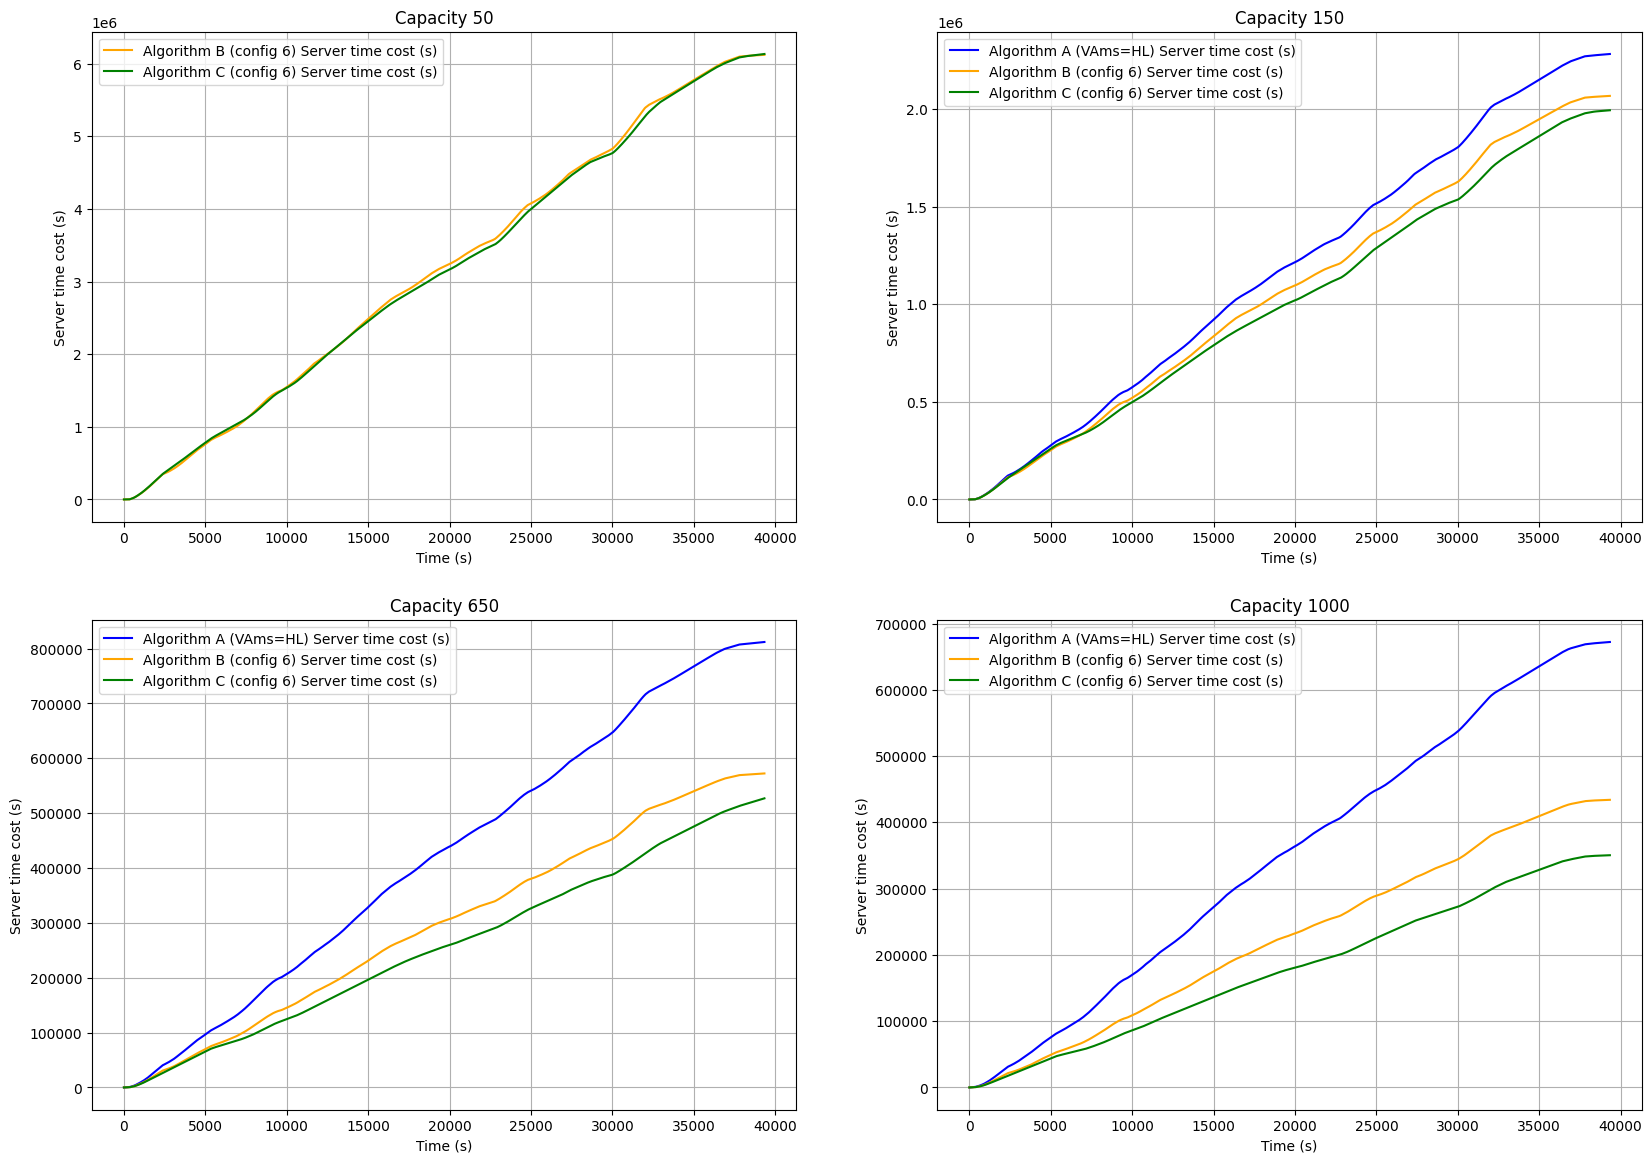

In [12]:
plot_all()

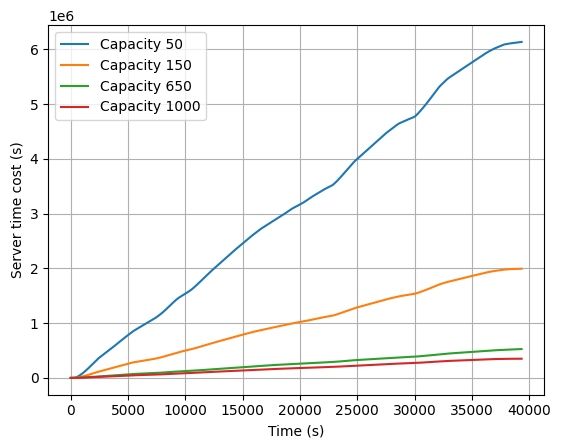

In [13]:
plot_c()

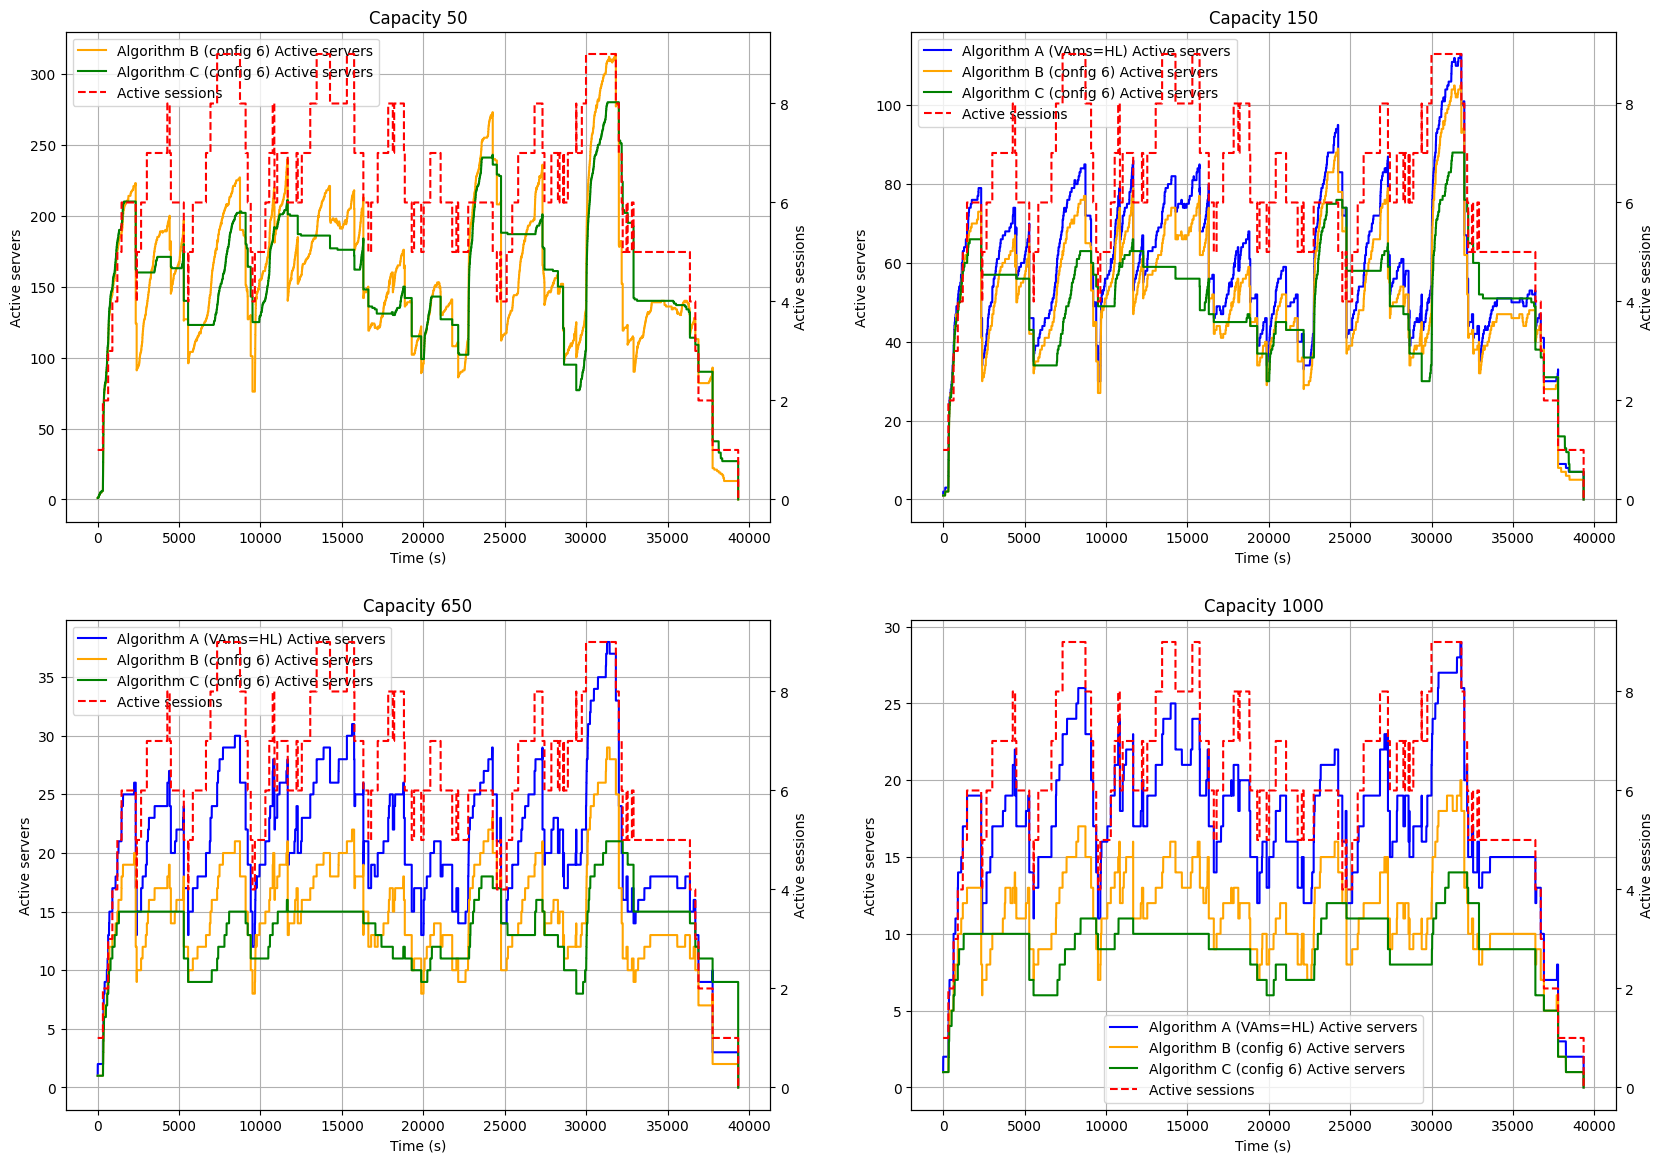

In [29]:
plot_all(["n_servers_current", "sessions"], ["Active servers", "Active sessions"])

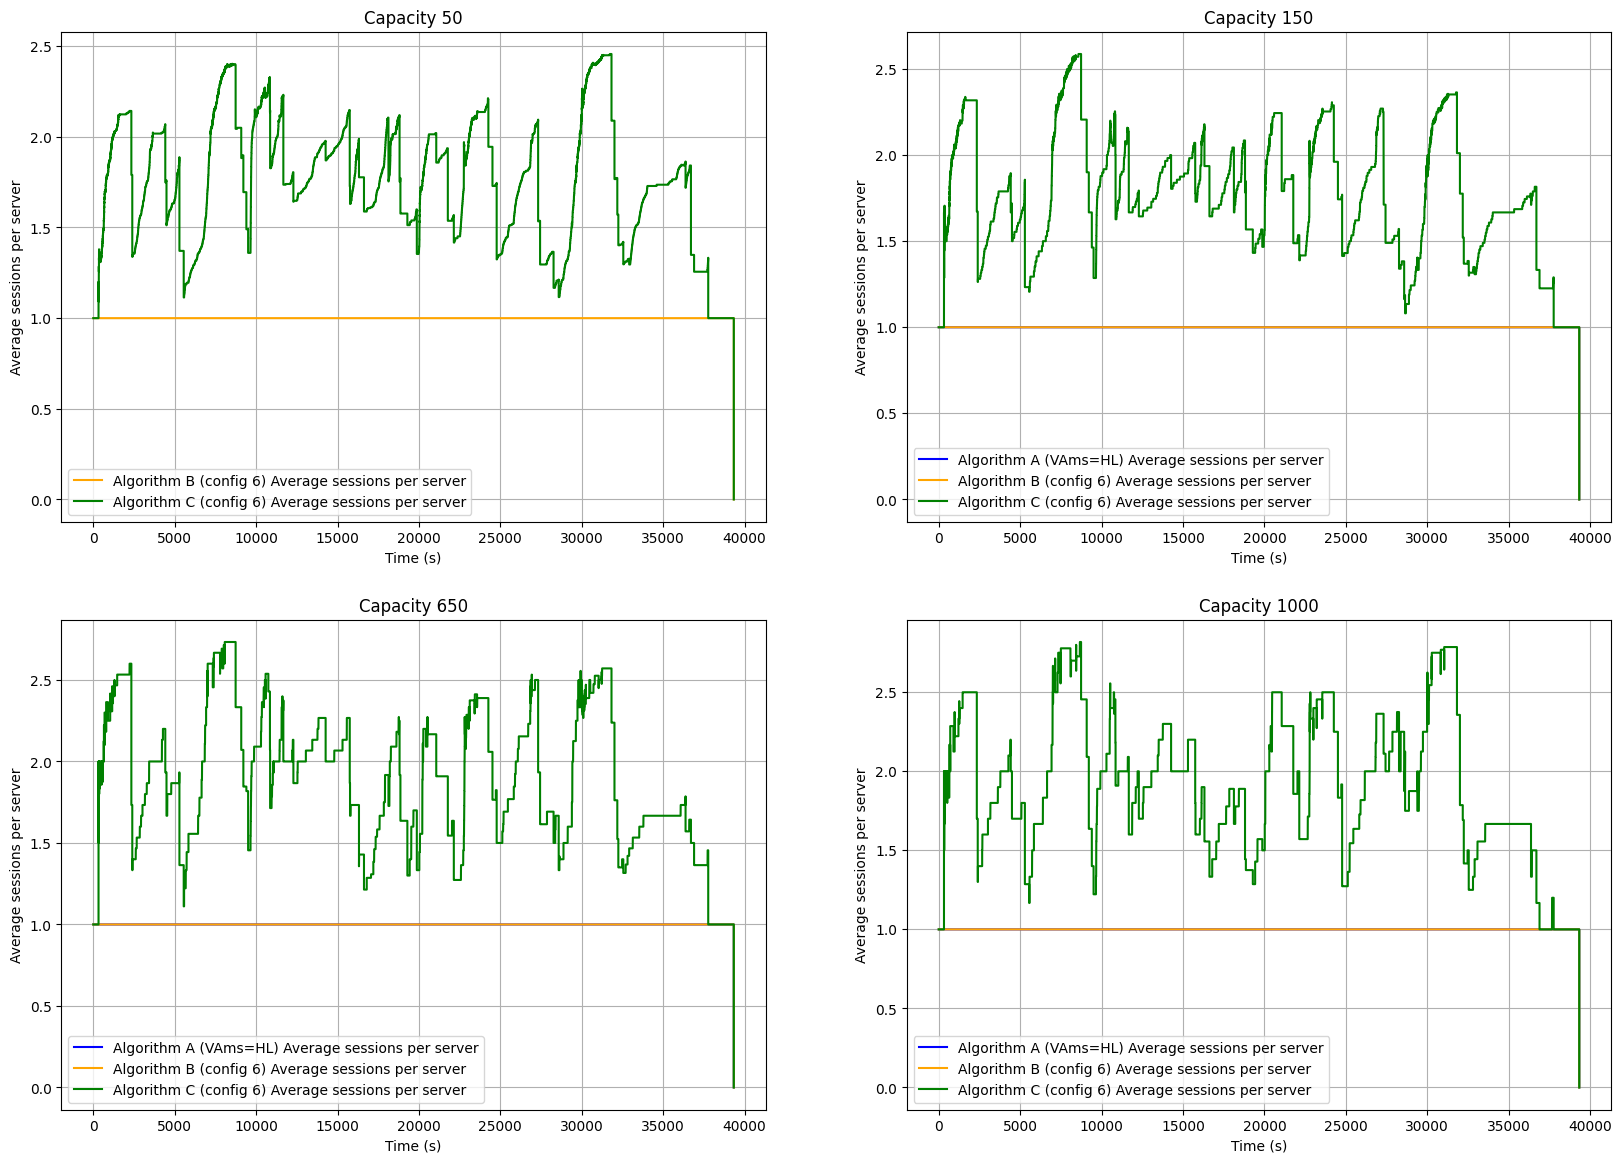

In [33]:
plot_all(["avg_streams_in"], ["Average sessions per server"])